=== PIPELINE KLASIFIKASI FASIES BERBASIS AI ===
Memindai direktori: C:\Users\kunde\1.2 Proyek Petrofisika
✅ Ditemukan 1 file LAS. Memproses file pertama: 'MSDR-03.las'

[Memuat AI ke dalam Memori...]
✅ Model AI, Scaler, dan Encoder berhasil dimuat!

[1/4] Membuka file data sumur: 'MSDR-03.las'...
      Sensor berhasil dipetakan: {'GR': 'GR', 'RHOB': 'RHOZ', 'NPHI': 'NPHI', 'RT': 'RLA5'}
[2/4] Membersihkan data (Menghapus kedalaman tanpa bacaan sensor)...
[3/4] Melakukan Preprocessing & Sequence Windowing...
[4/4] Mengeksekusi Prediksi Kecerdasan Buatan (BiLSTM)...
220/220 [==============================] - 2s 4ms/step
      Prediksi Selesai! Menyiapkan data untuk visualisasi.

[Merender Visualisasi] Membuka grafik interaktif di Web Browser...


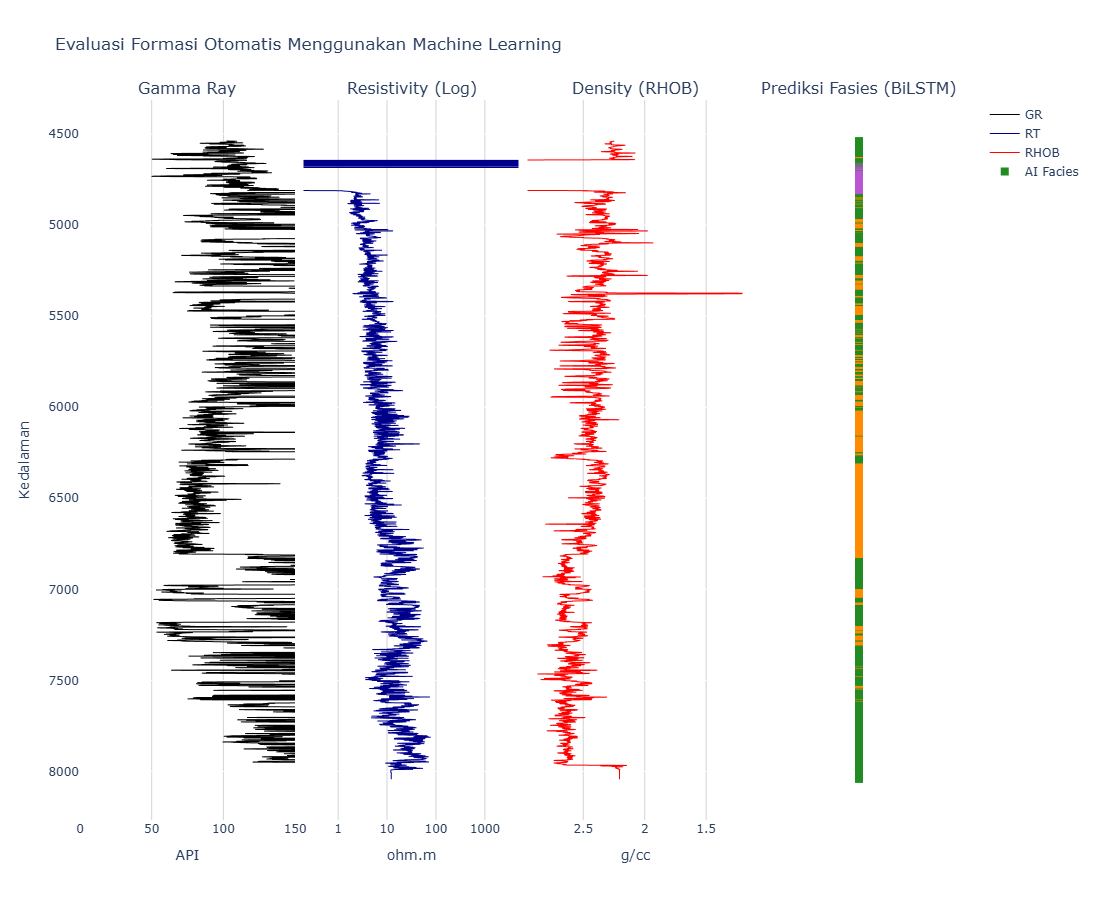


🎉 SELAMAT! Interpretasi sumur otomatis telah berhasil diselesaikan.


In [5]:
import os
import glob
import lasio
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# 1. FUNGSI PENCARIAN FILE LAS OTOMATIS
# ==========================================
def cari_file_las_di_direktori():
    """Mencari file .las di direktori tempat script ini dijalankan."""
    path_saat_ini = os.getcwd()
    print(f"Memindai direktori: {path_saat_ini}")
    
    files = glob.glob("*.las")
    
    if not files:
        print("❌ ERROR: Tidak ditemukan file .las di direktori ini.")
        return None
    
    print(f"✅ Ditemukan {len(files)} file LAS. Memproses file pertama: '{files[0]}'")
    return files[0]

# ==========================================
# 2. FUNGSI PREDIKSI MODEL PADA DATA LAS
# ==========================================
def terapkan_bilstm_ke_las(file_path, model_ai, scaler_train, encoder_train, window_size=11):
    print(f"\n[1/4] Membuka file data sumur: '{file_path}'...")
    try:
        las = lasio.read(file_path)
    except Exception as e:
        print(f"❌ Gagal membaca file LAS: {e}")
        return None

    df_las = las.df()
    df_las['Depth'] = df_las.index
    
    # Mapping otomatis untuk mengakomodasi berbagai nama sensor dari perusahaan logging
    mapping_alias = {
        'GR': ['GR', 'GAMMA', 'GR_EDTC', 'GR_ARC'],
        'RHOB': ['RHOB', 'ZDEN', 'DEN', 'RHOZ', 'DENB'],
        'NPHI': ['NPHI', 'CNC', 'TNPH', 'NPHI_LS'],
        'RT': ['RT', 'LLD', 'ILD', 'RESD', 'AT90', 'RLA5', 'RLA3']
    }

    kolom_final = {}
    for standar, alias in mapping_alias.items():
        found = False
        for a in alias:
            if a in df_las.columns:
                kolom_final[standar] = a
                found = True
                break
        if not found:
            print(f"⚠️ PERINGATAN: Sensor untuk '{standar}' tidak ditemukan!")
            print(f"Kolom yang tersedia di file LAS: {df_las.columns.tolist()}")
            return None

    print(f"      Sensor berhasil dipetakan: {kolom_final}")

    print("[2/4] Membersihkan data (Menghapus kedalaman tanpa bacaan sensor)...")
    df_bersih = df_las.dropna(subset=list(kolom_final.values())).copy()
    
    print("[3/4] Melakukan Preprocessing & Sequence Windowing...")
    # 1. Scaling menggunakan Scaler dari proses Training (SANGAT PENTING!)
    X_raw = df_bersih[list(kolom_final.values())].values
    X_scaled = scaler_train.transform(X_raw)

    # 2. Sequence Windowing (Membuat konteks spasial untuk LSTM)
    half_window = window_size // 2
    X_seq = []
    kedalaman_valid = []

    for i in range(half_window, len(X_scaled) - half_window):
        X_seq.append(X_scaled[i - half_window : i + half_window + 1])
        kedalaman_valid.append(df_bersih['Depth'].iloc[i])

    X_seq = np.array(X_seq)

    print("[4/4] Mengeksekusi Prediksi Kecerdasan Buatan (BiLSTM)...")
    pred_prob = model_ai.predict(X_seq)
    pred_classes = np.argmax(pred_prob, axis=1)
    
    # Mengembalikan prediksi angka menjadi label teks Fasies
    pred_labels = encoder_train.inverse_transform(pred_classes)

    # Membungkus hasil ke dalam DataFrame
    df_hasil = pd.DataFrame({
        'Depth': kedalaman_valid,
        'GR': df_bersih[kolom_final['GR']].iloc[half_window:-half_window].values,
        'RT': df_bersih[kolom_final['RT']].iloc[half_window:-half_window].values,
        'RHOB': df_bersih[kolom_final['RHOB']].iloc[half_window:-half_window].values,
        'NPHI': df_bersih[kolom_final['NPHI']].iloc[half_window:-half_window].values,
        'Predicted_Facies': pred_labels
    })

    print("      Prediksi Selesai! Menyiapkan data untuk visualisasi.")
    return df_hasil

# ==========================================
# 3. VISUALISASI HASIL PREDIKSI (PLOTLY WEBGL)
# ==========================================
def plot_interaktif_las(df_res):
    print("\n[Merender Visualisasi] Membuka grafik interaktif di Web Browser...")
    
    fig = make_subplots(
        rows=1, cols=4, shared_yaxes=True, horizontal_spacing=0.01,
        subplot_titles=('Gamma Ray', 'Resistivity (Log)', 'Density (RHOB)', 'Prediksi Fasies (BiLSTM)')
    )

    # Track 1-3: Kurva Log Standar (Akselerasi WebGL)
    fig.add_trace(go.Scattergl(
        x=df_res['GR'], y=df_res['Depth'], mode='lines', line=dict(color='black', width=1), 
        name='GR', hovertemplate='Depth: %{y:.2f}m<br>GR: %{x:.2f}<extra></extra>'
    ), row=1, col=1)
    
    fig.add_trace(go.Scattergl(
        x=df_res['RT'], y=df_res['Depth'], mode='lines', line=dict(color='darkblue', width=1), 
        name='RT', hovertemplate='Depth: %{y:.2f}m<br>RT: %{x:.2f}<extra></extra>'
    ), row=1, col=2)
    
    fig.add_trace(go.Scattergl(
        x=df_res['RHOB'], y=df_res['Depth'], mode='lines', line=dict(color='red', width=1), 
        name='RHOB', hovertemplate='Depth: %{y:.2f}m<br>RHOB: %{x:.2f}<extra></extra>'
    ), row=1, col=3)

    # Skala Warna Khusus untuk 6 Fasies
    fasies_to_num = {'Sandstone': 0, 'Shale': 1, 'Shaly Sand': 2, 'Limestone': 3, 'Dolomite': 4, 'Coal': 5}
    z_pred = [fasies_to_num.get(f, 1) for f in df_res['Predicted_Facies']] # Default ke 1 (Shale) jika anomali
    
    custom_colors = [
        [0.0, 'gold'], [1/6, 'gold'], 
        [1/6, 'forestgreen'], [2/6, 'forestgreen'], 
        [2/6, 'darkorange'], [3/6, 'darkorange'], 
        [3/6, 'lightskyblue'], [4/6, 'lightskyblue'], 
        [4/6, 'mediumorchid'], [5/6, 'mediumorchid'], 
        [5/6, 'black'], [1.0, 'black']
    ]

    # Track 4: Blok Warna Prediksi Litologi
    fig.add_trace(go.Scattergl(
        x=[1] * len(df_res), y=df_res['Depth'], mode='markers',
        marker=dict(color=z_pred, colorscale=custom_colors, cmin=-0.5, cmax=5.5, symbol='square', size=8, line=dict(width=0)),
        name='AI Facies', text=df_res['Predicted_Facies'],
        hovertemplate='Depth: %{y:.2f}m<br>Fasies: %{text}<extra></extra>'
    ), row=1, col=4)

    # Pengaturan Tampilan Akhir
    fig.update_layout(
        title='Evaluasi Formasi Otomatis Menggunakan Machine Learning', 
        height=900, plot_bgcolor='white', hovermode='y unified'
    )
    
    fig.update_xaxes(title_text="API", range=[0, 150], row=1, col=1, showgrid=True, gridcolor='lightgray')
    fig.update_xaxes(title_text="ohm.m", type="log", range=[np.log10(0.2), np.log10(5000)], row=1, col=2, showgrid=True, gridcolor='lightgray')
    fig.update_xaxes(title_text="g/cc", range=[2.95, 1.2], row=1, col=3, showgrid=True, gridcolor='lightgray')
    fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False, range=[0.5, 1.5], row=1, col=4)
    
    # Sumbu Y (Depth) dibalik agar makin dalam ke bawah
    fig.update_yaxes(title_text="Kedalaman", autorange="reversed", row=1, col=1)

    fig.show()

# ==========================================
# BLOK EKSEKUSI UTAMA (DEPLOYMENT)
# ==========================================
if __name__ == "__main__":
    print("=== PIPELINE KLASIFIKASI FASIES BERBASIS AI ===")
    
    # 1. Mencari data LAS
    target_las = cari_file_las_di_direktori()
    
    if target_las:
        print("\n[Memuat AI ke dalam Memori...]")
        try:
            # 2. Memuat Model dan Tools Preprocessing yang sudah dilatih
            model_terlatih = load_model("model_bilstm_fasies.h5")
            scaler_terlatih = joblib.load("scaler_fasies.pkl")
            encoder_terlatih = joblib.load("encoder_fasies.pkl")
            print("✅ Model AI, Scaler, dan Encoder berhasil dimuat!")
            
            # 3. Proses Analisis Utama
            df_hasil = terapkan_bilstm_ke_las(target_las, model_terlatih, scaler_terlatih, encoder_terlatih)
            
            # 4. Tampilkan Hasil
            if df_hasil is not None:
                plot_interaktif_las(df_hasil)
                print("\n🎉 SELAMAT! Interpretasi sumur otomatis telah berhasil diselesaikan.")
                
        except FileNotFoundError as e:
            print(f"\n❌ ERROR FILES MISSING: {e}")
            print("Pastikan file 'model_bilstm_fasies.h5', 'scaler_fasies.pkl', dan 'encoder_fasies.pkl'")
            print("sudah dibuat di script training sebelumnya dan berada di folder yang sama dengan skrip ini.")